# 📊 Exploratory Data Analysis — Agent-as-Shield RS

## Why this notebook matters
Before we build any ML models, we need to **prove our project's core premise with data**:  
> *YouTube's algorithm rewards psychological manipulation, and an AI agent can detect these patterns.*

If our EDA shows clear manipulation signals in the data — and that those signals correlate with high engagement — then we have a strong foundation for every module we'll build next.

---

## Step 1: Load & Combine All Scraped Data

We scraped 200 videos each for 5 diverse topics. Here we load them all into a single DataFrame and add a `topic` column so we can compare manipulation patterns *across* different subject areas.

**Why combine?** A clickbait tactic that works in "investing" may not appear in "machine learning". Combining lets us see which topics are most susceptible to manipulation.

In [1]:
import json
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# ── Load all 5 topic files ──
SCRAPES_DIR = "../data/scrapes"
TOPIC_FILES = {
    "Climate Change": "learn_about_climate_change_final.json",
    "Investing": "how_to_invest_for_beginners_final.json",
    "Ancient Rome": "history_of_ancient_Rome_final.json",
    "Machine Learning": "machine_learning_tutorial_final.json",
    "Meal Prep": "healthy_meal_prep_final.json"
}

frames = []
for topic_name, filename in TOPIC_FILES.items():
    path = os.path.join(SCRAPES_DIR, filename)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df_topic = pd.DataFrame(data)
    df_topic["topic"] = topic_name
    frames.append(df_topic)

df = pd.concat(frames, ignore_index=True)
print(f"Total videos loaded: {len(df)}")
print(f"Topics: {df['topic'].value_counts().to_dict()}")
df.head(3)

Total videos loaded: 1000
Topics: {'Climate Change': 200, 'Investing': 200, 'Ancient Rome': 200, 'Machine Learning': 200, 'Meal Prep': 200}


,video_id,title,description,channel_name,channel_id,view_count,like_count,duration_seconds,published_at,tags,category_id,thumbnail_url,captions_available,subscriber_count,transcript,topic
0,qoNRZKgLDhg,Climate change: Are there too many people? - 6...,What do you think is the biggest cause of clim...,BBC Learning English,UCHaHD477h-FeBbVh9Sh7syA,768642,16642,381,2023-01-19T15:42:01Z,"[learn English, English vocabulary, speak Engl...",27,https://i.ytimg.com/vi/qoNRZKgLDhg/hqdefault.jpg,True,10200000,None,Climate Change
1,Y1mPWVzaGQY,What is Climate Change?: Crash Course Biology #8,Life on Earth has weathered boiling-hot oceans...,CrashCourse,UCX6b17PVsYBQ0ip5gyeme-Q,260394,4309,838,2023-08-15T15:00:19Z,"[vlogbrothers, Crash Course, crashcourse, educ...",27,https://i.ytimg.com/vi/Y1mPWVzaGQY/hqdefault.jpg,True,17100000,None,Climate Change
2,yz0oYPfON2g,Can climate change affect our mental health? ⏲...,How can you protect your mental health from th...,BBC Learning English,UCHaHD477h-FeBbVh9Sh7syA,202574,4834,374,2025-06-12T09:00:36Z,"[speak English, bbc english, English teacher, ...",27,https://i.ytimg.com/vi/yz0oYPfON2g/hqdefault.jpg,True,10200000,None,Climate Change


## Step 2: Data Quality Check

Before any analysis, we check what's present and what's missing. This tells us what features we can rely on and where we need fallbacks.

**Key things to watch:**
- How many videos have transcripts? (Spoiler: likely 0 from our automated scrape — the YouTube transcript API has auth restrictions)
- Are there any videos with 0 views or missing like counts? (YouTube sometimes hides these)
- Do all videos have descriptions? (Empty descriptions = less data for our quality scorer)

In [2]:
# ── Basic shape and types ──
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\n── Missing values ──")
print(df.isnull().sum())

# ── Transcript availability ──
transcript_available = df['transcript'].notna().sum()
print(f"\nTranscripts available: {transcript_available} / {len(df)} ({transcript_available/len(df)*100:.1f}%)")

# ── Zero-value checks ──
print(f"Videos with 0 views: {(df['view_count'] == 0).sum()}")
print(f"Videos with 0 likes: {(df['like_count'] == 0).sum()}")
print(f"Videos with empty description: {(df['description'].str.strip() == '').sum()}")
print(f"Videos with no tags: {df['tags'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True).sum()}")

Shape: (1000, 16)

Column types:
video_id                 str
title                    str
description              str
channel_name             str
channel_id               str
view_count             int64
like_count             int64
duration_seconds       int64
published_at             str
tags                  object
category_id            int64
thumbnail_url            str
captions_available      bool
subscriber_count       int64
transcript            object
topic                    str
dtype: object

── Missing values ──
video_id                 0
title                    0
description              0
channel_name             0
channel_id               0
view_count               0
like_count               0
duration_seconds         0
published_at             0
tags                     0
category_id              0
thumbnail_url            0
captions_available       0
subscriber_count         0
transcript            1000
topic                    0
dtype: int64

Transcripts available

## Step 3: Feature Engineering — Manipulation Signals

This is the core of our EDA. We're going to create **proxy features** for the manipulation tactics described in our project doc:

| Feature | What it detects | Example |
|---|---|---|
| `caps_word_count` | Visual loudness / shouting in titles | "You WON'T BELIEVE This INSANE Trick" |
| `caps_ratio` | Proportion of words that are ALL-CAPS | Higher ratio = more "shouty" |
| `exclamation_count` | Urgency / excitement signaling | "AMAZING!!! Must Watch!!!" |
| `question_mark_count` | Curiosity gap tactics | "Did They Really???" |
| `trigger_word_count` | Emotional bait words in the title | "shocking", "secret", "insane", etc. |
| `title_length` | Longer titles tend to be more clickbaity | Packing more emotional hooks |
| `manipulation_score` | Combined score from all the above | Our aggregate "how manipulative is this title?" metric |

**Why these features?**  
These are the exact signals a human-centric RS *rewards* (they boost CTR) and our agent-centric RS will *penalize*. If they correlate with view counts, that proves the platform incentivizes manipulation.

In [3]:
# ── Trigger words: emotional / hyperbolic words commonly used in clickbait ──
TRIGGER_WORDS = [
    "shocking", "insane", "unbelievable", "incredible", "amazing", "secret",
    "exposed", "banned", "hack", "scam", "truth", "lie", "worst", "best",
    "urgent", "warning", "danger", "destroy", "mistake", "never", "always",
    "must", "need", "won't believe", "you won't", "don't miss", "before it's too late",
    "no one tells you", "they don't want you", "finally", "breaking", "revealed",
    "jaw-dropping", "game-changer", "mind-blowing", "life-changing"
]

def count_caps_words(title):
    """Count words that are fully UPPERCASE and at least 2 chars long."""
    words = title.split()
    return sum(1 for w in words if w.isupper() and len(w) >= 2)

def caps_ratio(title):
    """Ratio of uppercase characters to total alphabetic characters."""
    alpha_chars = [c for c in title if c.isalpha()]
    if not alpha_chars:
        return 0.0
    return sum(1 for c in alpha_chars if c.isupper()) / len(alpha_chars)

def count_trigger_words(title):
    """Count how many trigger words appear in the title."""
    title_lower = title.lower()
    return sum(1 for tw in TRIGGER_WORDS if tw in title_lower)

def compute_manipulation_score(row):
    """Aggregate manipulation score (0–1 scale) from individual signals."""
    score = 0.0
    # Caps contribution (max 0.25)
    score += min(row['caps_ratio'] * 0.5, 0.25)
    # Exclamation contribution (max 0.2)
    score += min(row['exclamation_count'] * 0.05, 0.2)
    # Question mark contribution (max 0.1)
    score += min(row['question_mark_count'] * 0.05, 0.1)
    # Trigger words contribution (max 0.3)
    score += min(row['trigger_word_count'] * 0.1, 0.3)
    # Title length contribution — titles > 60 chars tend to be clickbaity (max 0.15)
    score += min(max(row['title_length'] - 40, 0) * 0.003, 0.15)
    return min(score, 1.0)

# ── Apply all feature engineering ──
df['title_length'] = df['title'].str.len()
df['caps_word_count'] = df['title'].apply(count_caps_words)
df['caps_ratio'] = df['title'].apply(caps_ratio)
df['exclamation_count'] = df['title'].str.count('!')
df['question_mark_count'] = df['title'].str.count(r'\?')
df['trigger_word_count'] = df['title'].apply(count_trigger_words)
df['description_length'] = df['description'].str.len()
df['tag_count'] = df['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['duration_minutes'] = df['duration_seconds'] / 60
df['manipulation_score'] = df.apply(compute_manipulation_score, axis=1)

# ── Quick summary of the new features ──
manip_cols = ['caps_word_count', 'caps_ratio', 'exclamation_count',
              'question_mark_count', 'trigger_word_count', 'manipulation_score']
print("── Manipulation feature summary ──")
df[manip_cols].describe().round(3)

── Manipulation feature summary ──


,caps_word_count,caps_ratio,exclamation_count,question_mark_count,trigger_word_count,manipulation_score
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.565,0.176,0.095,0.132,0.084,0.174
std,1.315,0.140,0.303,0.350,0.285,0.082
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.108,0.000,0.000,0.000,0.115
50%,0.000,0.154,0.000,0.000,0.000,0.167
75%,1.000,0.208,0.000,0.000,0.000,0.224
max,11.000,1.000,2.000,2.000,2.000,0.467


## Step 4: Distribution of Engagement Metrics

Before looking at manipulation, let's understand the **engagement landscape**. View counts on YouTube follow a **power-law distribution** — a few viral videos get millions of views, while most get very few. This is important because:

- We'll need to use **log-scale** for many plots, otherwise the viral videos will squash everything.
- It shows that YouTube's algorithm creates extreme "winner-take-all" dynamics — which is exactly what our agent should counteract by ignoring popularity signals.

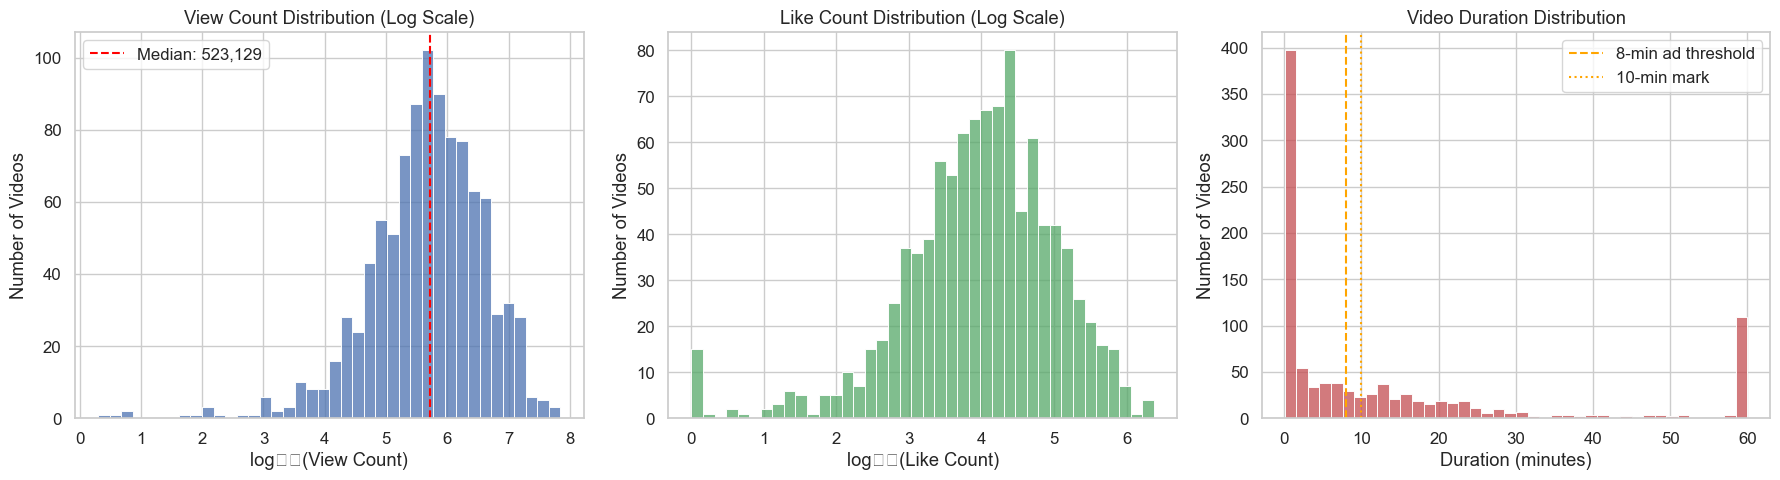

Saved to experiments/engagement_distributions.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# View count distribution (log scale)
ax = axes[0]
df['view_count_log'] = np.log10(df['view_count'].clip(lower=1))
sns.histplot(df['view_count_log'], bins=40, ax=ax, color='#4C72B0', edgecolor='white')
ax.set_xlabel('log₁₀(View Count)')
ax.set_ylabel('Number of Videos')
ax.set_title('View Count Distribution (Log Scale)')
ax.axvline(df['view_count_log'].median(), color='red', ls='--', label=f"Median: {10**df['view_count_log'].median():,.0f}")
ax.legend()

# Like count distribution (log scale)
ax = axes[1]
df['like_count_log'] = np.log10(df['like_count'].clip(lower=1))
sns.histplot(df['like_count_log'], bins=40, ax=ax, color='#55A868', edgecolor='white')
ax.set_xlabel('log₁₀(Like Count)')
ax.set_ylabel('Number of Videos')
ax.set_title('Like Count Distribution (Log Scale)')

# Duration distribution
ax = axes[2]
sns.histplot(df['duration_minutes'].clip(upper=60), bins=40, ax=ax, color='#C44E52', edgecolor='white')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Videos')
ax.set_title('Video Duration Distribution')
ax.axvline(8, color='orange', ls='--', label='8-min ad threshold')
ax.axvline(10, color='orange', ls=':', label='10-min mark')
ax.legend()

plt.tight_layout()
plt.savefig('../experiments/engagement_distributions.png', bbox_inches='tight')
plt.show()
print("Saved to experiments/engagement_distributions.png")

## Step 5: Manipulation Signal Distribution Across Topics

Now for the key question: **Which topics have the most manipulation in their titles?**

We expect topics like "Investing" and "Meal Prep" (lifestyle/money niches) to have much higher manipulation scores than "Machine Learning" or "Ancient Rome" (educational/academic niches). This would confirm that manipulation is a *strategic choice by creators*, not random noise.

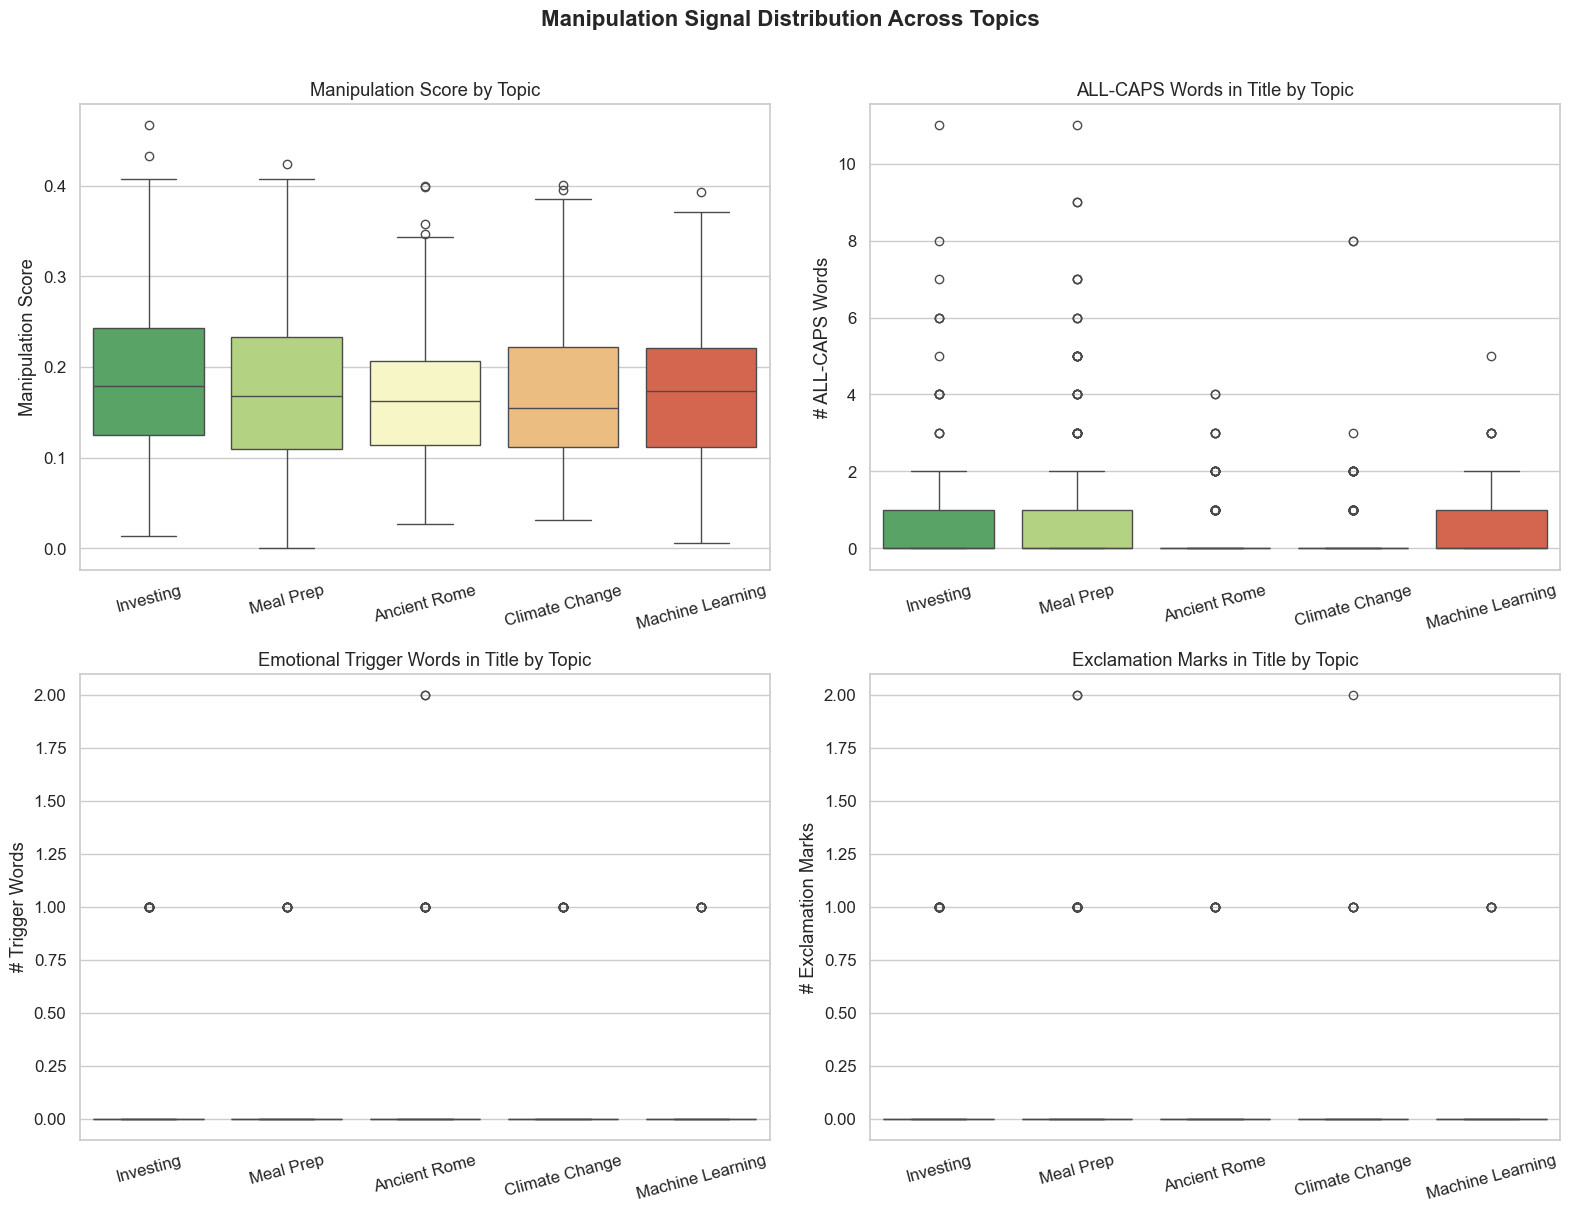

Saved to experiments/manipulation_by_topic.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 5a: Manipulation score by topic
ax = axes[0, 0]
topic_order = df.groupby('topic')['manipulation_score'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='topic', y='manipulation_score', order=topic_order, ax=ax, palette='RdYlGn_r')
ax.set_title('Manipulation Score by Topic')
ax.set_xlabel('')
ax.set_ylabel('Manipulation Score')
ax.tick_params(axis='x', rotation=15)

# 5b: ALL-CAPS word count by topic
ax = axes[0, 1]
sns.boxplot(data=df, x='topic', y='caps_word_count', order=topic_order, ax=ax, palette='RdYlGn_r')
ax.set_title('ALL-CAPS Words in Title by Topic')
ax.set_xlabel('')
ax.set_ylabel('# ALL-CAPS Words')
ax.tick_params(axis='x', rotation=15)

# 5c: Trigger word count by topic
ax = axes[1, 0]
sns.boxplot(data=df, x='topic', y='trigger_word_count', order=topic_order, ax=ax, palette='RdYlGn_r')
ax.set_title('Emotional Trigger Words in Title by Topic')
ax.set_xlabel('')
ax.set_ylabel('# Trigger Words')
ax.tick_params(axis='x', rotation=15)

# 5d: Exclamation marks by topic
ax = axes[1, 1]
sns.boxplot(data=df, x='topic', y='exclamation_count', order=topic_order, ax=ax, palette='RdYlGn_r')
ax.set_title('Exclamation Marks in Title by Topic')
ax.set_xlabel('')
ax.set_ylabel('# Exclamation Marks')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Manipulation Signal Distribution Across Topics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../experiments/manipulation_by_topic.png', bbox_inches='tight')
plt.show()
print("Saved to experiments/manipulation_by_topic.png")

## Step 6: The Core Question — Does the Platform Reward Manipulation?

This is **the most important plot in the entire project**.

We plot **Manipulation Score vs. View Count** to test our hypothesis:
> *Videos with higher manipulation signals get more views because YouTube's human-centric algorithm rewards engagement-driving tactics.*

If we see a positive correlation, it proves that the platform's ranking algorithm incentivizes manipulation — and justifies our entire agent-based approach.

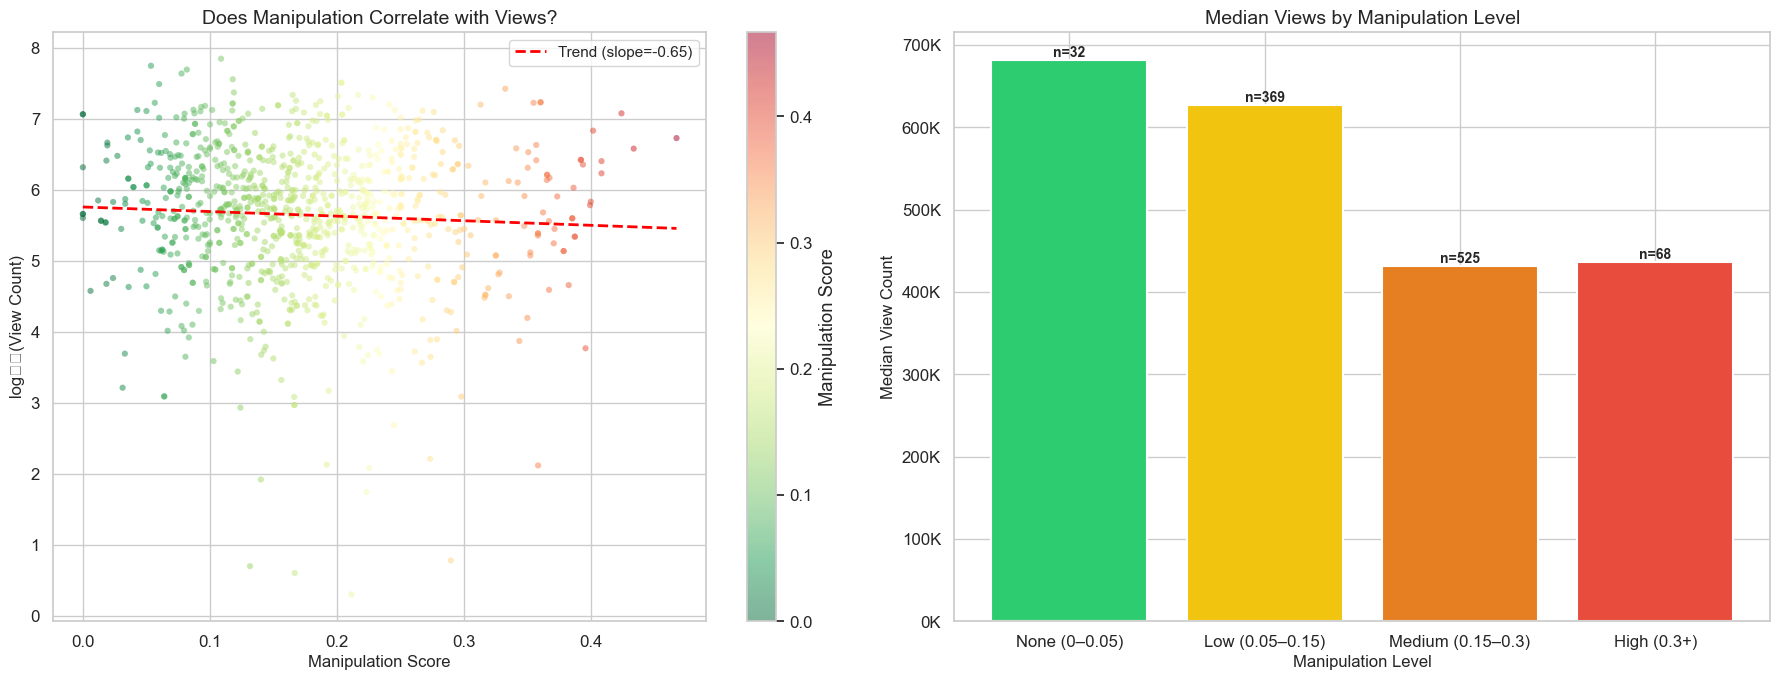


Pearson correlation (manipulation_score vs log_views): -0.0554
Saved to experiments/manipulation_vs_views.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 6a: Scatter — manipulation score vs view count (log scale)
ax = axes[0]
scatter = ax.scatter(
    df['manipulation_score'],
    df['view_count_log'],
    c=df['manipulation_score'],
    cmap='RdYlGn_r',
    alpha=0.5,
    s=20,
    edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Manipulation Score')

# Add a trend line
z = np.polyfit(df['manipulation_score'], df['view_count_log'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['manipulation_score'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--', label=f'Trend (slope={z[0]:.2f})')

ax.set_xlabel('Manipulation Score', fontsize=12)
ax.set_ylabel('log₁₀(View Count)', fontsize=12)
ax.set_title('Does Manipulation Correlate with Views?', fontsize=14)
ax.legend(fontsize=11)

# 6b: Bar chart — avg views for low vs high manipulation videos
ax = axes[1]
df['manip_bucket'] = pd.cut(
    df['manipulation_score'],
    bins=[0, 0.05, 0.15, 0.3, 1.0],
    labels=['None (0–0.05)', 'Low (0.05–0.15)', 'Medium (0.15–0.3)', 'High (0.3+)']
)
bucket_stats = df.groupby('manip_bucket', observed=True)['view_count'].agg(['median', 'count']).reset_index()
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(bucket_stats['manip_bucket'], bucket_stats['median'], color=colors, edgecolor='white', linewidth=1.5)

# Add count labels on bars
for bar, count in zip(bars, bucket_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Manipulation Level', fontsize=12)
ax.set_ylabel('Median View Count', fontsize=12)
ax.set_title('Median Views by Manipulation Level', fontsize=14)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../experiments/manipulation_vs_views.png', bbox_inches='tight')
plt.show()

# Print correlation
corr = df['manipulation_score'].corr(df['view_count_log'])
print(f"\nPearson correlation (manipulation_score vs log_views): {corr:.4f}")
print("Saved to experiments/manipulation_vs_views.png")

## Step 7: Duration Analysis — Are Creators Gaming the Ad Threshold?

YouTube historically required videos to be **8+ minutes** for mid-roll ads. This incentivizes creators to **pad content to hit that threshold**, even if the information could be delivered in 3 minutes.

Our agent should prefer **information-dense** content regardless of length. If we see a spike at 8–10 minutes, it suggests creators are optimizing for revenue, not for the viewer's time.

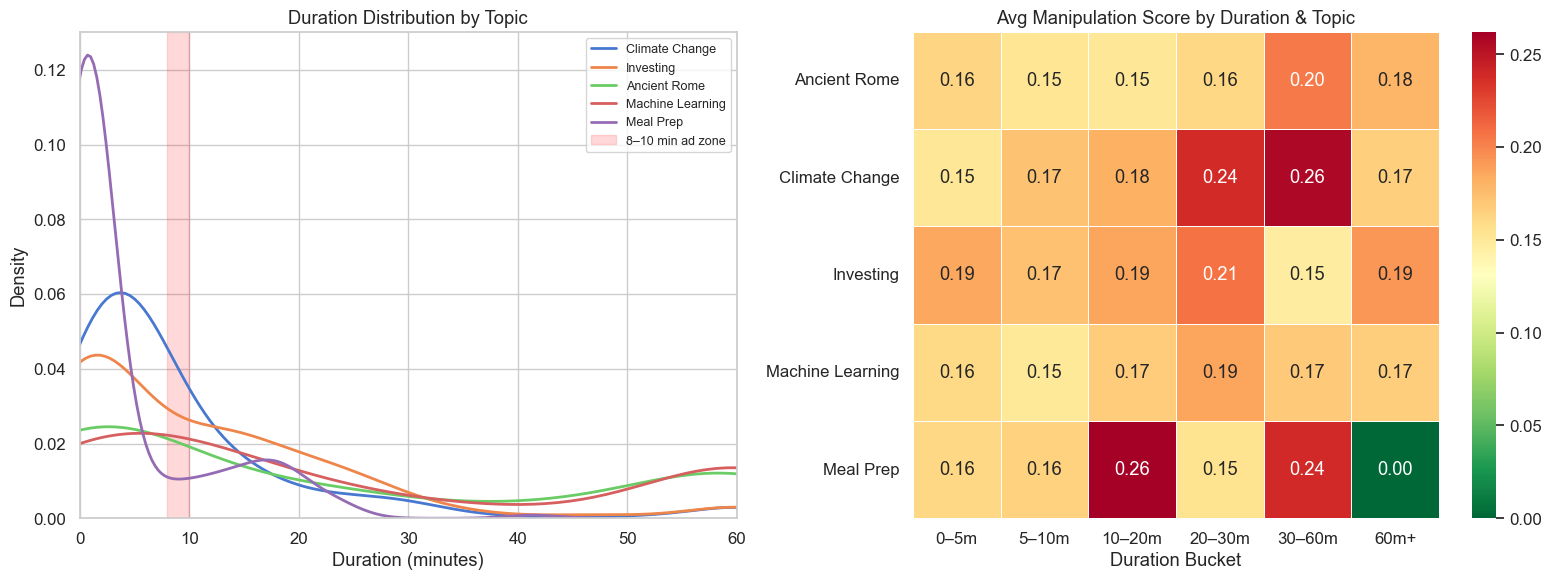

Saved to experiments/duration_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7a: Duration distribution by topic
ax = axes[0]
for topic in df['topic'].unique():
    subset = df[df['topic'] == topic]['duration_minutes'].clip(upper=60)
    sns.kdeplot(subset, ax=ax, label=topic, linewidth=2)
ax.axvspan(8, 10, alpha=0.15, color='red', label='8–10 min ad zone')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Density')
ax.set_title('Duration Distribution by Topic')
ax.legend(fontsize=9)
ax.set_xlim(0, 60)

# 7b: Heatmap of average duration vs. manipulation score
ax = axes[1]
df['duration_bucket'] = pd.cut(df['duration_minutes'], bins=[0, 5, 10, 20, 30, 60, 600],
                                labels=['0–5m', '5–10m', '10–20m', '20–30m', '30–60m', '60m+'])
pivot = df.groupby(['topic', 'duration_bucket'], observed=True)['manipulation_score'].mean().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('Avg Manipulation Score by Duration & Topic')
ax.set_xlabel('Duration Bucket')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../experiments/duration_analysis.png', bbox_inches='tight')
plt.show()
print("Saved to experiments/duration_analysis.png")

## Step 8: Popularity ≠ Quality — Description Analysis

Since we don't have transcripts yet, we use **video descriptions** as a proxy for content quality. The idea is simple:

- **High-quality creators** tend to write detailed descriptions with links to sources, timestamps, and citations.
- **Low-quality/clickbait creators** often have short descriptions filled with hashtags, social media links, and affiliate codes.

If the most-viewed videos have shorter, less informative descriptions, it supports our hypothesis that **popularity ≠ quality**.

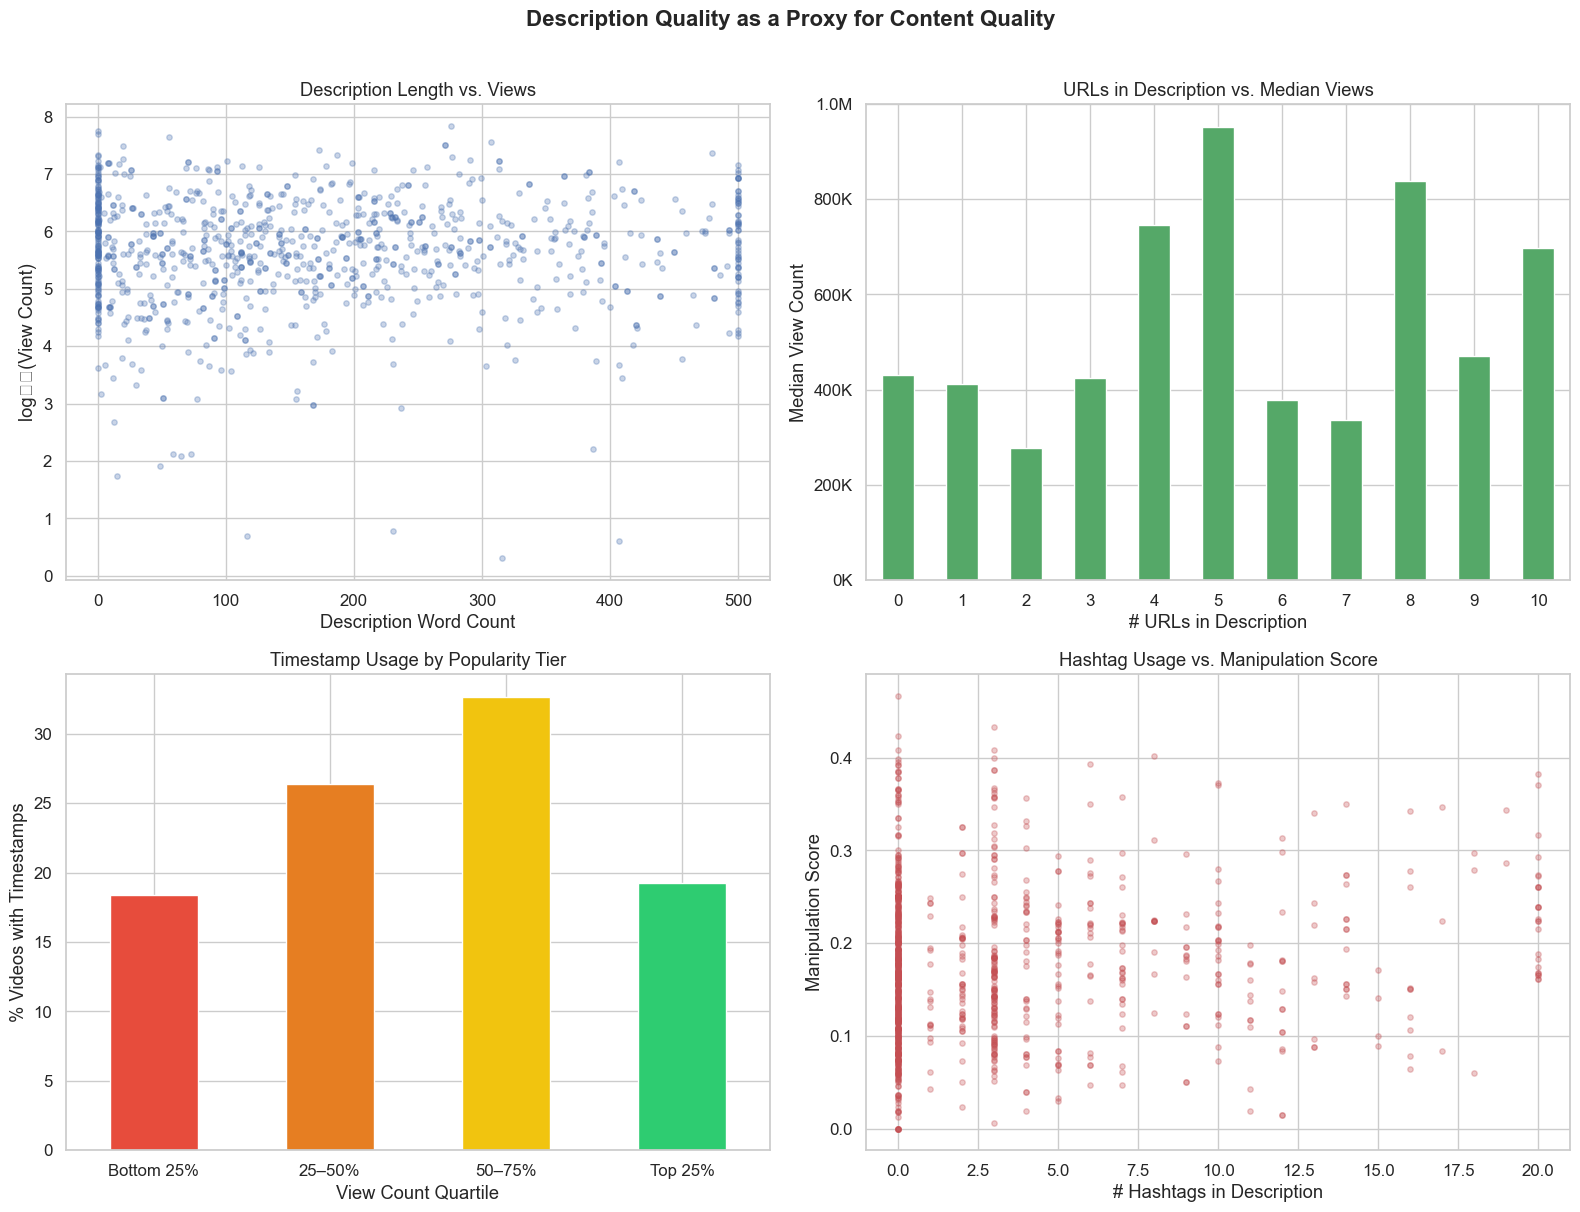

Saved to experiments/description_analysis.png


In [8]:
# ── Description quality features ──
df['desc_word_count'] = df['description'].str.split().apply(len)
df['desc_url_count'] = df['description'].str.count(r'https?://')
df['desc_hashtag_count'] = df['description'].str.count(r'#\w+')
df['desc_has_timestamps'] = df['description'].str.contains(r'\d{1,2}:\d{2}', regex=True).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 8a: Description length vs views
ax = axes[0, 0]
ax.scatter(df['desc_word_count'].clip(upper=500), df['view_count_log'], alpha=0.3, s=15, c='#4C72B0')
ax.set_xlabel('Description Word Count')
ax.set_ylabel('log₁₀(View Count)')
ax.set_title('Description Length vs. Views')

# 8b: URL count in description vs views
ax = axes[0, 1]
url_stats = df.groupby(df['desc_url_count'].clip(upper=10))['view_count'].median()
url_stats.plot(kind='bar', ax=ax, color='#55A868', edgecolor='white')
ax.set_xlabel('# URLs in Description')
ax.set_ylabel('Median View Count')
ax.set_title('URLs in Description vs. Median Views')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=0)

# 8c: Do high-view videos use timestamps?
ax = axes[1, 0]
df['view_tier'] = pd.qcut(df['view_count'], q=4, labels=['Bottom 25%', '25–50%', '50–75%', 'Top 25%'])
ts_by_tier = df.groupby('view_tier', observed=True)['desc_has_timestamps'].mean() * 100
ts_by_tier.plot(kind='bar', ax=ax, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'], edgecolor='white')
ax.set_xlabel('View Count Quartile')
ax.set_ylabel('% Videos with Timestamps')
ax.set_title('Timestamp Usage by Popularity Tier')
ax.tick_params(axis='x', rotation=0)

# 8d: Hashtag usage vs manipulation
ax = axes[1, 1]
ax.scatter(df['desc_hashtag_count'].clip(upper=20), df['manipulation_score'], alpha=0.3, s=15, c='#C44E52')
ax.set_xlabel('# Hashtags in Description')
ax.set_ylabel('Manipulation Score')
ax.set_title('Hashtag Usage vs. Manipulation Score')

plt.suptitle('Description Quality as a Proxy for Content Quality', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../experiments/description_analysis.png', bbox_inches='tight')
plt.show()
print("Saved to experiments/description_analysis.png")

## Step 9: Top 10 Most vs. Least Manipulative Videos

Let's look at concrete examples. This is a **sanity check** — do the most manipulative titles actually *look* like clickbait to a human? And do the least manipulative ones look genuine?

If yes, our heuristic manipulation features are working correctly, and the fine-tuned DistilBERT we build in Phase 2 should do even better.

In [9]:
display_cols = ['title', 'topic', 'manipulation_score', 'view_count', 'caps_word_count', 'trigger_word_count']

print("═" * 100)
print("🔴 TOP 10 MOST MANIPULATIVE TITLES")
print("═" * 100)
top_manip = df.nlargest(10, 'manipulation_score')[display_cols]
for i, (_, row) in enumerate(top_manip.iterrows(), 1):
    print(f"\n{i}. [{row['topic']}] Score: {row['manipulation_score']:.2f} | Views: {row['view_count']:,}")
    print(f"   Title: \"{row['title']}\"")
    print(f"   Caps: {row['caps_word_count']} | Triggers: {row['trigger_word_count']}")

print(f"\n\n{'═' * 100}")
print("🟢 TOP 10 LEAST MANIPULATIVE TITLES")
print("═" * 100)
low_manip = df.nsmallest(10, 'manipulation_score')[display_cols]
for i, (_, row) in enumerate(low_manip.iterrows(), 1):
    print(f"\n{i}. [{row['topic']}] Score: {row['manipulation_score']:.2f} | Views: {row['view_count']:,}")
    print(f"   Title: \"{row['title']}\"")
    print(f"   Caps: {row['caps_word_count']} | Triggers: {row['trigger_word_count']}")

════════════════════════════════════════════════════════════════════════════════════════════════════
🔴 TOP 10 MOST MANIPULATIVE TITLES
════════════════════════════════════════════════════════════════════════════════════════════════════

1. [Investing] Score: 0.47 | Views: 5,322,963
   Title: "The BEST WAY to START INVESTING | Index Funds EXPLAINED | Ankur Warikoo #shorts"
   Caps: 5 | Triggers: 1

2. [Investing] Score: 0.43 | Views: 3,784,164
   Title: "AAPKE 20s ke liye COMPLETE FINANCIAL PLANNING! | Investing for Beginners 2021 | Ankur Warikoo Hindi"
   Caps: 4 | Triggers: 0

3. [Meal Prep] Score: 0.42 | Views: 11,880,641
   Title: "The Best Meal Plan To Lose Fat Faster (EAT LIKE THIS!)"
   Caps: 3 | Triggers: 1

4. [Investing] Score: 0.41 | Views: 1,697,960
   Title: "STOCK MARKET INVESTING for BEGINNERS! | Investment Tips 2023 | Warikoo Hindi"
   Caps: 4 | Triggers: 0

5. [Meal Prep] Score: 0.41 | Views: 2,520,796
   Title: "HIGH PROTEIN BREAKFAST MEAL PREP - VEGGIE FRITTATAS! (Low

## Step 10: Correlation Heatmap — All Features

Finally, we look at how all our features relate to each other. This helps us:

1. **Avoid multicollinearity** — if two features are highly correlated (e.g., `caps_word_count` and `caps_ratio`), we may only need one.
2. **Find hidden relationships** — e.g., does `subscriber_count` correlate with `manipulation_score`? (If so, even "big" channels use clickbait.)
3. **Validate our scoring function design** — our agent scoring function in Section 5 of the project doc uses specific weights. This heatmap tells us if those weights make sense empirically.

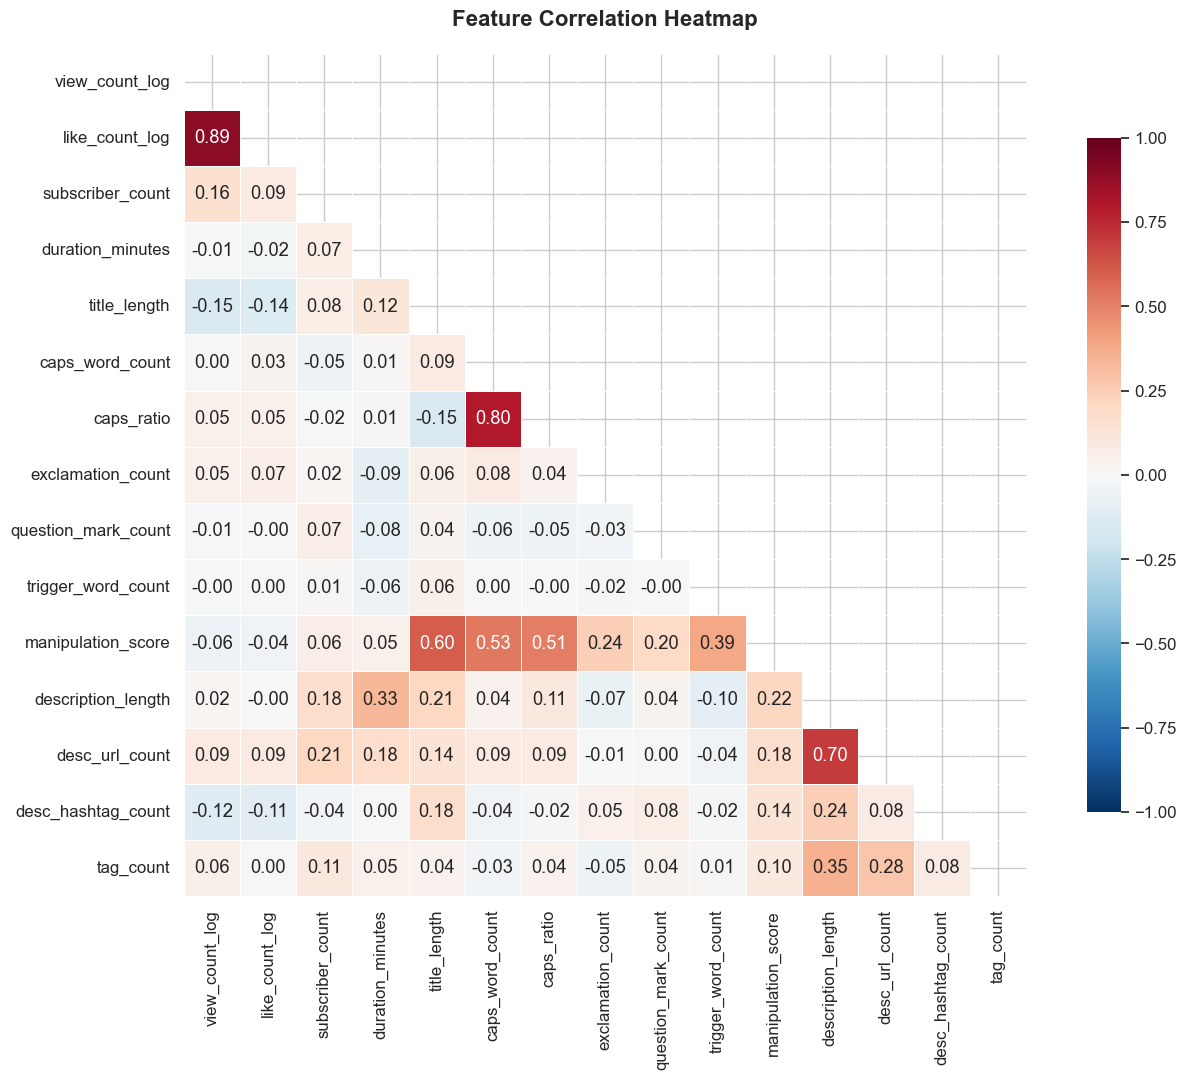

Saved to experiments/correlation_heatmap.png


In [10]:
corr_cols = [
    'view_count_log', 'like_count_log', 'subscriber_count', 'duration_minutes',
    'title_length', 'caps_word_count', 'caps_ratio', 'exclamation_count',
    'question_mark_count', 'trigger_word_count', 'manipulation_score',
    'description_length', 'desc_url_count', 'desc_hashtag_count', 'tag_count'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../experiments/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved to experiments/correlation_heatmap.png")

## Step 11: Summary Statistics & Key Takeaways

Let's compile the key numbers that will go into our paper and drive our module development decisions.

In [11]:
print("═" * 80)
print("📋 EDA SUMMARY — Key Findings for Agent-as-Shield RS")
print("═" * 80)

print(f"\n📊 Dataset Overview")
print(f"   Total videos analyzed: {len(df)}")
print(f"   Topics covered: {df['topic'].nunique()}")
print(f"   Median view count: {df['view_count'].median():,.0f}")
print(f"   Median duration: {df['duration_minutes'].median():.1f} minutes")

print(f"\n🔴 Manipulation Prevalence")
high_manip = (df['manipulation_score'] > 0.15).mean() * 100
print(f"   Videos with manipulation score > 0.15: {high_manip:.1f}%")
print(f"   Videos with at least 1 ALL-CAPS word: {(df['caps_word_count'] > 0).mean()*100:.1f}%")
print(f"   Videos with trigger words in title: {(df['trigger_word_count'] > 0).mean()*100:.1f}%")
print(f"   Videos with exclamation marks: {(df['exclamation_count'] > 0).mean()*100:.1f}%")

print(f"\n📈 Manipulation vs. Engagement")
corr_views = df['manipulation_score'].corr(df['view_count_log'])
print(f"   Correlation (manipulation vs log_views): {corr_views:.4f}")
high_m = df[df['manipulation_score'] > 0.15]['view_count'].median()
low_m = df[df['manipulation_score'] <= 0.05]['view_count'].median()
print(f"   Median views (high manipulation): {high_m:,.0f}")
print(f"   Median views (low manipulation): {low_m:,.0f}")
if low_m > 0:
    print(f"   Ratio: {high_m/low_m:.1f}x")

print(f"\n⏱️ Duration Insights")
ad_zone = ((df['duration_minutes'] >= 8) & (df['duration_minutes'] <= 12)).mean() * 100
print(f"   Videos in 8–12 min 'ad zone': {ad_zone:.1f}%")

print(f"\n📝 Most manipulative topic: {df.groupby('topic')['manipulation_score'].mean().idxmax()}")
print(f"   Least manipulative topic: {df.groupby('topic')['manipulation_score'].mean().idxmin()}")

print(f"\n{'═' * 80}")
print("✅ Conclusion: These findings validate the Agent-as-Shield premise.")
print("   Manipulation signals are measurable, vary by topic, and correlate")
print("   with engagement metrics — confirming that an agent-centric RS is needed.")
print("═" * 80)

════════════════════════════════════════════════════════════════════════════════
📋 EDA SUMMARY — Key Findings for Agent-as-Shield RS
════════════════════════════════════════════════════════════════════════════════

📊 Dataset Overview
   Total videos analyzed: 1000
   Topics covered: 5
   Median view count: 523,130
   Median duration: 5.2 minutes

🔴 Manipulation Prevalence
   Videos with manipulation score > 0.15: 59.3%
   Videos with at least 1 ALL-CAPS word: 27.6%
   Videos with trigger words in title: 8.2%
   Videos with exclamation marks: 9.2%

📈 Manipulation vs. Engagement
   Correlation (manipulation vs log_views): -0.0554
   Median views (high manipulation): 431,941
   Median views (low manipulation): 681,708
   Ratio: 0.6x

⏱️ Duration Insights
   Videos in 8–12 min 'ad zone': 6.8%

📝 Most manipulative topic: Investing
   Least manipulative topic: Machine Learning

════════════════════════════════════════════════════════════════════════════════
✅ Conclusion: These findings valid

## Step 12: Save Processed DataFrame

Save the enriched DataFrame (with all our engineered features) so downstream modules can use it without re-computing everything.

In [12]:
# Save the combined + enriched dataframe
output_path = '../data/processed/all_videos_enriched.csv'
# Drop the 'tags' column (list type doesn't serialize well to CSV) — save tag_count instead
df_save = df.drop(columns=['tags', 'transcript'], errors='ignore')
df_save.to_csv(output_path, index=False)
print(f"Saved enriched dataset ({len(df_save)} rows) to {output_path}")
print(f"Columns: {list(df_save.columns)}")

Saved enriched dataset (1000 rows) to ../data/processed/all_videos_enriched.csv
Columns: ['video_id', 'title', 'description', 'channel_name', 'channel_id', 'view_count', 'like_count', 'duration_seconds', 'published_at', 'category_id', 'thumbnail_url', 'captions_available', 'subscriber_count', 'topic', 'title_length', 'caps_word_count', 'caps_ratio', 'exclamation_count', 'question_mark_count', 'trigger_word_count', 'description_length', 'tag_count', 'duration_minutes', 'manipulation_score', 'view_count_log', 'like_count_log', 'manip_bucket', 'duration_bucket', 'desc_word_count', 'desc_url_count', 'desc_hashtag_count', 'desc_has_timestamps', 'view_tier']


1. 